# 02 · Connectome vs controls

Runs an experiment from a config and shows the tables and figures. Same thing as `scripts/run_experiment.py`, just interactive.

If the connectome data isn't downloaded yet it runs the offline synthetic demo instead (the summary says so at the top).

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)  # configs and data paths are relative to the repo root

from IPython.display import Markdown, display

from flyres import plotting
from flyres.config import load_config
from flyres.connectome import FILES, cache_stem
from flyres.experiment import run_experiment

have_real = Path(f"data/cache/{cache_stem(5)}.npz").exists() or all((Path("data/raw") / f).exists() for f in FILES.values())
CONFIG = "configs/small.yaml" if have_real else "configs/demo_synthetic.yaml"
cfg = load_config(CONFIG)
print("config:", CONFIG)

config: configs/small.yaml


In [2]:
result = run_experiment(cfg)  # a few minutes for small.yaml

subgraph: using cached grow_n3000_w5_a6fdabec
data: SPY 2003-09-26 to 2026-03-26 (5,660 rows)
running 25 reservoir jobs (5 wirings x 5 seeds)


  [1/25] connectome         seed 0: 3.0s


  [2/25] connectome         seed 1: 2.9s


  [3/25] connectome         seed 2: 2.7s


  [4/25] connectome         seed 3: 2.7s


...

  [22/25] erdos_renyi        seed 1: 3.4s


  [23/25] erdos_renyi        seed 2: 3.3s


  [24/25] erdos_renyi        seed 3: 2.8s


  [25/25] erdos_renyi        seed 4: 2.8s


done in 78s, results in results/small


In [3]:
display(Markdown(result.summary))

# flybrain-reservoir: small

Run 2026-09-26 15:47. Connectome: male CNS v1.0, >= 5 synapses per edge. Market data: yfinance.

- Reservoir: 3,000 neurons (grow), 100 input neurons, readout from 300 neurons + the raw inputs (relative penalty 0.001); spectral radius 0.9 (spectral), leak 1.0, weights log1p
- Wirings: connectome, degree_preserving, weight_shuffle, sign_shuffle, erdos_renyi. Seeds: 5. Horizon: 1 day(s). Costs: 1.0 bps per unit turnover. Positions: sign.

## SPY: out-of-sample, 2007-09-26 to 2026-03-26 (18.5 years)

Up days in the test period: 55.1% (an always-long model gets this hit rate).

| model | IC | hit rate | Sharpe (net) | Sharpe (gross) | ann. return | max drawdown | turnover |
|---|---|---|---|---|---|---|---|
| connectome | 0.015 ± 0.007 | 0.536 ± 0.004 | 0.51 ± 0.03 | 0.55 ± 0.03 | 0.100 ± 0.006 | -0.33 ± 0.01 | 0.33 ± 0.04 |
| degree_preserving | 0.014 ± 0.004 | 0.533 ± 0.001 | 0.48 ± 0.13 | 0.52 ± 0.13 | 0.094 ± 0.026 | -0.40 ± 0.03 | 0.36 ± 0.03 |
| weight_shuffle | 0.014 ± 0.003 | 0.535 ± 0.004 | 0.45 ± 0.08 | 0.49 ± 0.08 | 0.089 ± 0.016 | -0.37 ± 0.04 | 0.32 ± 0.04 |
| sign_shuffle | 0.013 ± 0.006 | 0.535 ± 0.003 | 0.45 ± 0.09 | 0.49 ± 0.09 | 0.090 ± 0.018 | -0.38 ± 0.06 | 0.33 ± 0.04 |
| erdos_renyi | 0.015 ± 0.003 | 0.534 ± 0.001 | 0.47 ± 0.08 | 0.52 ± 0.08 | 0.094 ± 0.015 | -0.37 ± 0.03 | 0.35 ± 0.01 |
| linear_features | -0.006 | 0.538 | 0.35 | 0.37 | 0.069 | -0.46 | 0.18 |
| ar | 0.002 | 0.542 | 0.59 | 0.61 | 0.117 | -0.34 | 0.21 |
| buy_hold | n/a | 0.551 | 0.59 | 0.59 | 0.117 | -0.55 | 0.00 |

### Connectome minus each alternative

Per-seed paired differences (t-test over seeds) and the Sharpe difference of the seed-averaged strategies (moving-block bootstrap, 95% CI).

| comparison | Δ IC | Δ hit rate | Δ Sharpe (net) | ensemble Δ Sharpe [95% CI] |
|---|---|---|---|---|
| connectome vs degree_preserving | +0.001 (p=0.84) | +0.003 (p=0.12) | +0.03 (p=0.66) | -0.06 [-0.27, +0.15] (p=0.61) |
| connectome vs weight_shuffle | +0.000 (p=0.93) | +0.001 (p=0.34) | +0.06 (p=0.15) | -0.01 [-0.12, +0.08] (p=0.78) |
| connectome vs sign_shuffle | +0.001 (p=0.39) | +0.002 (p=0.52) | +0.05 (p=0.34) | -0.02 [-0.18, +0.11] (p=0.77) |
| connectome vs erdos_renyi | -0.001 (p=0.90) | +0.002 (p=0.36) | +0.03 (p=0.47) | -0.01 [-0.17, +0.14] (p=0.92) |
| connectome vs linear_features | +0.020 | -0.002 | +0.16 | +0.14 [-0.08, +0.37] (p=0.22) |
| connectome vs ar | +0.013 | -0.006 | -0.08 | -0.10 [-0.39, +0.21] (p=0.53) |
| connectome vs buy_hold | n/a | -0.014 | -0.08 | -0.09 [-0.44, +0.24] (p=0.58) |

Rule of thumb: the standard error of an annualized Sharpe over 18 years is about 0.23, so differences much smaller than that are noise.

## Memory capacity (market-free benchmark)

Sum over delays 1..100 of R² for reconstructing past i.i.d. inputs. *With readout noise* adds noise of std 0.001 to every readout neuron (0.1% of its maximum activity) before fitting, so only memory that survives a little noise counts; the noise-free number is the standard benchmark but can come from fluctuations of a millionth.

| wiring | memory (noise-free) | connectome minus this | memory with readout noise | connectome minus this |
|---|---|---|---|---|
| connectome | 9.20 ± 0.21 | - | 2.79 ± 0.28 | - |
| degree_preserving | 10.17 ± 0.62 | -0.96 (p=0.02) | 5.78 ± 0.22 | -2.98 (p=0.00) |
| weight_shuffle | 9.21 ± 0.35 | -0.01 (p=0.92) | 3.00 ± 0.35 | -0.20 (p=0.01) |
| sign_shuffle | 9.72 ± 0.82 | -0.52 (p=0.20) | 4.27 ± 0.62 | -1.47 (p=0.00) |
| erdos_renyi | 10.99 ± 0.57 | -1.79 (p=0.00) | 6.84 ± 0.30 | -4.05 (p=0.00) |

## Wiring structure and dynamics

| wiring | edges | reciprocity | largest SCC | raw spectral radius | top mode spread | active readouts | unstable readouts |
|---|---|---|---|---|---|---|---|
| connectome | 200,172 | 0.360 | 0.99 | 251.71 ± 0.00 | ~112 of 3,000 | 19% | 0% |
| degree_preserving | 200,172 | 0.036 ± 0.001 | 0.99 ± 0.00 | 66.70 ± 2.74 | ~729 of 3,000 | 96% | 0% |
| weight_shuffle | 200,172 | 0.360 | 0.99 | 222.81 ± 0.76 | ~150 of 3,000 | 21% | 0% |
| sign_shuffle | 200,172 | 0.360 | 0.99 | 113.55 ± 22.64 | ~161 of 3,000 | 42% | 0% |
| erdos_renyi | 200,172 | 0.022 ± 0.001 | 1.00 | 54.40 ± 2.13 | ~1,675 of 3,000 | 100% | 0% |

- Raw spectral radius: the largest eigenvalue before rescaling; every weight is divided by it (times 0.9).
- Top mode spread: roughly how many of the network's neurons carry that eigenvalue. A tiny share (say a few hundred of 166,700) means a small dense hot spot sets the gain for the whole network (`scripts/hot_spots.py` shows where it is).
- Active readouts: share of readout neurons whose state varies by more than 0.001 under white-noise input (mean over seeds).
- Unstable readouts: share whose state still depends on inputs from hundreds of steps ago (worst seed). Should be 0% for a valid reservoir.

## Reading this

- p-values come from paired tests over seeds (seed = input weights, readout neurons, control randomness). They capture seed-to-seed variation, not luck in the market history; the ensemble bootstrap covers that part.
- A model that learns nothing predicts the average (positive) return and turns into buy & hold, so compare Sharpe against buy & hold and hit rate against the up-day rate. IC is the cleanest skill measure.
- Several comparisons are run at once, so expect the odd p < 0.05 by chance.


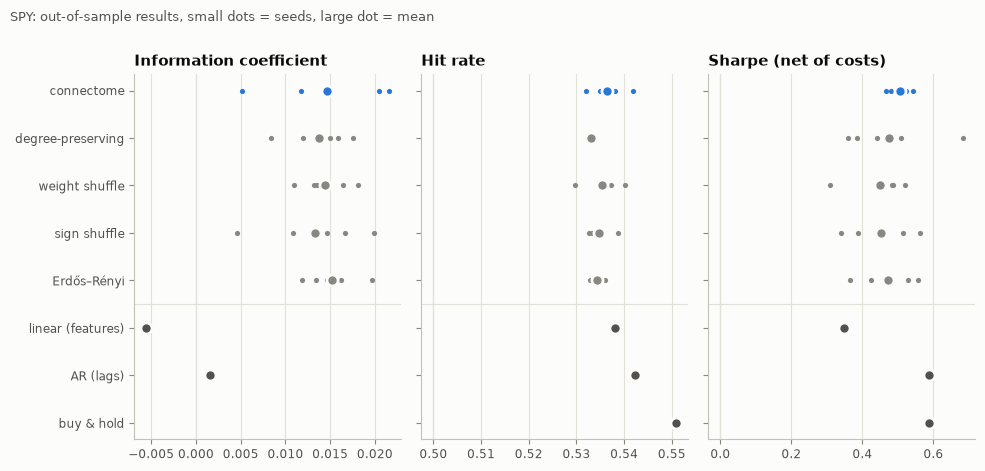

In [4]:
for ticker in result.ensemble_returns:
    plotting.plot_metric_strip(result.metrics, ticker)

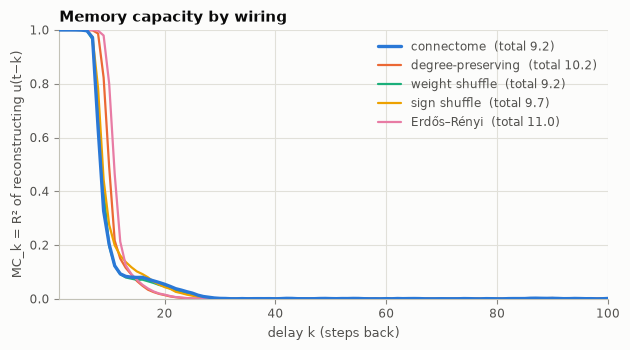

In [5]:
plotting.plot_memory_curves(result.memory);

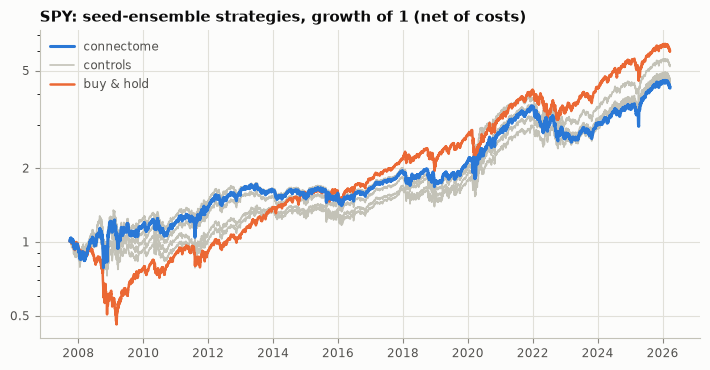

In [6]:
for ticker, ens in result.ensemble_returns.items():
    test = ens.dropna(how="all")
    plotting.plot_equity({c: test[c].to_numpy() for c in test.columns}, test.index,
                         title=f"{ticker}: seed-ensemble strategies, growth of 1 (net of costs)")

## What would count as evidence that the fly wiring is special

- The connectome beats **each** control with the same sign across seeds, not just on average.
- It survives multiple comparisons (five controls × several metrics is a lot of chances to get p < 0.05 by luck).
- The seed-ensemble bootstrap interval excludes zero.
- It shows up in memory capacity too, and at a second subgraph size (`--set subgraph.n_neurons=...`).

The most likely outcome on daily SPY is that nothing beats buy & hold or the linear baseline by a meaningful margin. That's fine: memory capacity is the cleaner test of whether biological wiring is special as a reservoir.